<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h1>LogisticRegression</h1>
<hr>
</div>

In [38]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score

In [39]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display
from scripts.decision_tree import determine_parameter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
    <p>Train-Test split is not required, as both dataset provided are separate.</p>
</div>

In [41]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [42]:
X_train = df.drop(columns=['Default', 'LoanID', 'DTIRatio', 'CreditScore'])
y_train = df['Default']
print(X_train.shape)
print(y_train.shape)

(255347, 14)
(255347,)


In [43]:
df_test = pd.read_csv("data/test.csv")
df_predictions = pd.read_csv("data/prediction_submission.csv")
df_test = pd.merge(left=df_test,right=df_predictions, left_on='LoanID',right_on='LoanID')
df_test.shape

(109435, 18)

In [44]:
y_test =  df_test['predicted_probability']
X_test = df_test.drop(columns=['LoanID', 'DTIRatio', 'CreditScore', 'predicted_probability'])
print(X_test.shape)
print(y_test.shape)

(109435, 14)
(109435,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

<div style="font-family: Calibri; font-size: 18px; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [50]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']),    
    # ], remainder=MinMaxScaler()
    ], remainder=Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=True)),
            ('scaler', StandardScaler())
        ])  
)

In [51]:
X_train = transformer.fit_transform(X_train)

In [52]:
X_test = transformer.transform(X_test)

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>3. PCA</h2>
</div>

In [64]:
from sklearn.decomposition import PCA

In [65]:
pca = PCA()

In [66]:
X_pca = pca.fit_transform(X_train)

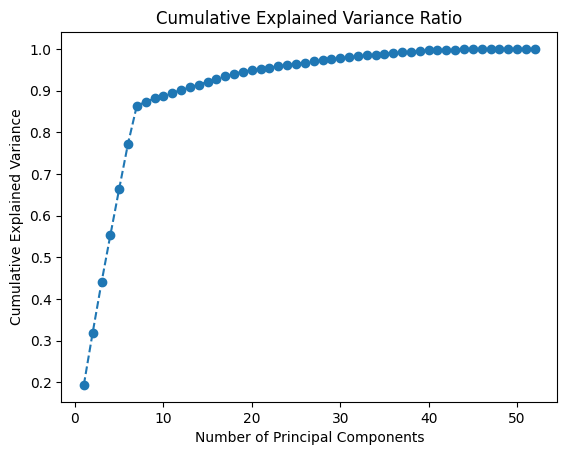

In [67]:
# Plot explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o' , linestyle='--')
plt.title('Cumulative Explained Variance Ratio') 
plt.xlabel('Number of Principal Components') 
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [68]:
# Determine the optimal number of components based on the explained variance
n_components = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"Number of components to retain 95% variance: {n_components}")

Number of components to retain 95% variance: 21


In [69]:
model = cv.best_estimator_
model

NameError: name 'cv' is not defined

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>3. LogisticRegression</h2>
</div>

In [57]:
from sklearn.linear_model import LogisticRegression

In [61]:
classifier = LogisticRegression(C = 0.01, random_state = 42)

In [62]:
classifier.fit(X_train,y_train)

LogisticRegression(C=0.01, random_state=42)

In [63]:
train_acc = classifier.score(X_train, y_train)
test_acc = classifier.score(X_test, y_test)

print(f'{"Training Accuracy:":<20}{train_acc:.2f}')
print(f'{"Test Accuracy:":<20}{test_acc:.2f}')

y_test_pred = classifier.predict(X_test)
print(f'{"Recall Score:":<20}{recall_score(y_test, y_test_pred, pos_label=1)}')
print(f'{"Precision Score:":<20}{precision_score(y_test, y_test_pred, pos_label=1)}')
print(f'{"RoC AuC Score:":<20}{roc_auc_score(y_test, y_test_pred)}')
f1 = f1_score(y_test, y_test_pred, pos_label=1)
print(f'{"F1 Score:":<20}{f1:.2}')

Training Accuracy:  0.89
Test Accuracy:      0.88
Recall Score:       0.009904128040567308
Precision Score:    0.12278978388998035
RoC AuC Score:      0.5003401277300777
F1 Score:           0.018


In [15]:
param_grid = [
    {
        'estimator__criterion': ["gini", "entropy"],
        'estimator__max_depth': range(10,20,1),
        'sampling_strategy': ['not majority', 'not majority']
    },
    {
        'estimator__criterion': ["gini", "entropy"],        
        'estimator__min_samples_split': np.arange(0.10,0.2,0.01),
        'estimator__min_samples_leaf': np.arange(0.15,0.20,0.01),
        'sampling_strategy': ['not majority', 'not majority'],
    },
    {    
        'estimator__criterion': ["gini", "entropy"],
        'estimator__max_depth': range(10,20,1),
        'sampling_strategy': ['not majority', 'not majority']
    },
    {
        'estimator__criterion': ["gini", "entropy"],
        'estimator__min_samples_split': np.arange(0.10,0.2,0.01),
        'sampling_strategy': ['not majority', 'not majority']        
    }
]

In [16]:
cv = GridSearchCV(classifier, param_grid, cv=5, n_jobs=-1, verbose=True, scoring=make_scorer(fbeta_score, beta=3, pos_label=1));

In [ ]:
cv.fit(X_train, y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


In [ ]:
print("Best Parameters:", cv.best_params_)
print("Best CV Score:", cv.best_score_)

In [ ]:
model = cv.best_estimator_
model

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, values_format='d', display_labels=["No","Yes"]);

In [ ]:
rs = recall_score(y_test, y_pred, pos_label=1)
ps = precision_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
ac = accuracy_score(y_test, y_pred)

In [ ]:
print(f"{'Recall Score:':<20}{rs:<5}")
print(f"{'Precision Score:':<20}{ps:<5}")
print(f"{'F1 Score:':<20}{f1:<5}")
print(f"{'Accuracy Score:':<20}{ac:<5}")

In [ ]:
y_train_pred_prob, y_test_pred_prob = calc_predict_proba(model, X_train, y_train, X_test, y_test)

In [ ]:
train_acc_list, test_acc_list, rs_list, ps_list, f1_list, ac_list = [],[],[],[],[],[]
for thresh in np.arange(0.3,0.8,0.1):
    train_acc, test_acc, rs, ps, f1, ac, y_test_pred = calc_scores(model, X_train, y_train, y_train_pred_prob, X_test, y_test, y_test_pred_prob, thresh)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    rs_list.append(rs) 
    ps_list.append(ps)
    f1_list.append(f1)
    ac_list.append(ac)

In [ ]:
plt.figure(figsize=(20, 8))

plt.plot(np.arange(0.3,0.8,0.1), train_acc_list, label='Training Accuracy', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), test_acc_list, label='Test Accuracy', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), rs_list, label='Recall Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ps_list, label='Precision Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), f1_list, label='F1 Score', marker='o')
plt.plot(np.arange(0.3,0.8,0.1), ac_list, label='Accuracy', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.legend()
plt.grid(True)
plt.show()